# Restaurant Vibe Classifier - Preprocessing, Fine-Tuning, and Evaluation

This notebook prepares the balanced restaurant vibe dataset for transformer-based classification and fine-tunes DistilBERT models to classify restaurant review/category inputs into vibe labels.

Main workflow:
1. Load balanced labeled dataset
2. Encode text labels into numeric IDs
3. Split data into train/validation/test sets
4. Tokenize text inputs for DistilBERT
5. Fine-tune multiple DistilBERT experiments
6. Compare model performance
7. Save the final model
8. Generate demo predictions and evaluation artifacts

The final task is supervised multi-class text classification.

In [37]:
import pandas as pd

df = pd.read_csv("../data/processed/labeled_input_text_balanced_2k_v03.csv")

df.head()

,input_text,vibe_label
0,"Categories: Restaurants, Fish & Chips, Food, S...",upscale
1,"Categories: Bars, American (Traditional), Gast...",date_night
2,"Categories: Bakeries, Food, Patisserie/Cake Sh...",study_spot
3,"Categories: Restaurants, Sushi Bars | Review: ...",late_night
4,"Categories: Delis, Sandwiches, American (New),...",study_spot


In [38]:
df.shape

(2000, 2)

## 1. Inspect Class Balance

This cell checks the distribution of vibe labels in the balanced dataset. A balanced label distribution is important because the model should learn each class rather than overfitting to one dominant category.

In [39]:
df["vibe_label"].value_counts()

vibe_label
date_night         286
study_spot         286
late_night         286
casual_hangout     286
family_friendly    286
upscale            285
trendy             285
Name: count, dtype: int64

## 2. Encode Labels

Transformer classification models require numeric class labels rather than string labels.

This mapping converts labels such as `date_night` and `study_spot` into integer class IDs. The reverse mapping is also created so predictions can later be converted back into readable vibe labels.

In [40]:
LABEL_TO_ID = {
    "date_night": 0,
    "study_spot": 1,
    "casual_hangout": 2,
    "family_friendly": 3,
    "upscale": 4,
    "trendy": 5,
    "late_night": 6
}

ID_TO_LABEL = {v: k for k, v in LABEL_TO_ID.items()}

df["label"] = df["vibe_label"].map(LABEL_TO_ID)

## 3. Verify Encoded Label Distribution

After encoding the labels, this cell checks the distribution of the numeric label IDs to confirm that encoding worked correctly.

In [41]:
df["label"].value_counts()

label
0    286
1    286
6    286
2    286
3    286
4    285
5    285
Name: count, dtype: int64

## 4. Verify Label Names

This cell confirms the unique string labels still present in the dataset. This is a useful sanity check before splitting the data. I originally added this part in because I had some unexpected NaN values I wasn't catching in later steps. 

In [42]:
print(df["vibe_label"].unique())

<ArrowStringArray>
[        'upscale',      'date_night',      'study_spot',      'late_night',
  'casual_hangout', 'family_friendly',          'trendy']
Length: 7, dtype: str


## 5. Create Train / Validation / Test Splits

The dataset is split into:
- training set
- validation set
- test set

Stratified splitting is used so each split preserves the class distribution as much as possible.

In [43]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=42
)

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

Train: (1400, 3)
Validation: (300, 3)
Test: (300, 3)


## 6. Save Dataset Splits

The train, validation, and test sets are exported to CSV files for reproducibility and future inspection.

In [44]:
train_df.to_csv("../data/splits/train.csv", index=False)
val_df.to_csv("../data/splits/val.csv", index=False)
test_df.to_csv("../data/splits/test.csv", index=False)

## 7. Check Core NLP Libraries

This cell verifies that the key libraries for transformer training are available in the local Python environment.

In [45]:
import transformers
import datasets
import torch

print(transformers.__version__)

5.8.1


## 8. Load DistilBERT Tokenizer

The tokenizer converts raw text into token IDs that DistilBERT can process.

In [46]:
from transformers import DistilBertTokenizer

tokenizer = DistilBertTokenizer.from_pretrained(
    "distilbert-base-uncased"
)

## 9. Inspect a Sample Input

Before tokenization, this cell prints one example input from the training set to confirm the final text format.

In [48]:
sample_text = train_df.iloc[0]["input_text"]

print(sample_text)

Categories: Bars, American (Traditional), Gastropubs, Nightlife, Cocktail Bars, Restaurants, American (New) | Review: My friend and I came for happy hour and we loved it! We got three things on the happy hour menu: the chicken & waffle bites, the sausage & garlic pizza, and the buffalo cauliflower. We also each got a Raspberry Smash to drink & they were pretty strong!

I loved the buffalo cauliflower. I make a baked version of this at home, so I was surprised when it came out fried, but it was DELICIOUS. My friend liked the sausage & garlic pizza but I thought the garlic was a bit too raw. The chicken & waffle bites were okay; neither of us liked them too much. I wouldn't order it again.

But our server was a sweetheart, which is why I'm giving Finney's five stars. He kept cracking jokes when he came by to check in on us. Made our experience even better! Overall this is a solid happy hour spot in SB.


## 10. Test Tokenization on One Example

This cell confirms that the tokenizer returns the expected fields, such as `input_ids` and `attention_mask`.

In [49]:
tokens = tokenizer(sample_text)

print(tokens.keys())

KeysView({'input_ids': [101, 7236, 1024, 6963, 1010, 2137, 1006, 3151, 1007, 1010, 3806, 13181, 14289, 5910, 1010, 2305, 15509, 1010, 18901, 6963, 1010, 7884, 1010, 2137, 1006, 2047, 1007, 1064, 3319, 1024, 2026, 2767, 1998, 1045, 2234, 2005, 3407, 3178, 1998, 2057, 3866, 2009, 999, 2057, 2288, 2093, 2477, 2006, 1996, 3407, 3178, 12183, 1024, 1996, 7975, 1004, 11333, 18142, 15424, 1010, 1996, 24165, 1004, 20548, 10733, 1010, 1998, 1996, 6901, 6187, 15859, 14156, 1012, 2057, 2036, 2169, 2288, 1037, 20710, 2361, 9766, 15132, 2000, 4392, 1004, 2027, 2020, 3492, 2844, 999, 1045, 3866, 1996, 6901, 6187, 15859, 14156, 1012, 1045, 2191, 1037, 17776, 2544, 1997, 2023, 2012, 2188, 1010, 2061, 1045, 2001, 4527, 2043, 2009, 2234, 2041, 13017, 1010, 2021, 2009, 2001, 12090, 1012, 2026, 2767, 4669, 1996, 24165, 1004, 20548, 10733, 2021, 1045, 2245, 1996, 20548, 2001, 1037, 2978, 2205, 6315, 1012, 1996, 7975, 1004, 11333, 18142, 15424, 2020, 3100, 1025, 4445, 1997, 2149, 4669, 2068, 2205, 2172, 1012

## 11. Define Tokenization Function

This function applies tokenizer settings to every dataset example.

The tokenizer:
- pads inputs to a fixed length
- truncates long reviews
- prepares text for DistilBERT training

In [50]:
def tokenize_function(examples):
    return tokenizer(
        examples["input_text"],
        padding="max_length",
        truncation=True,
        max_length=500
    )

## 12. Convert pandas DataFrames to Hugging Face Datasets

Hugging Face `Dataset` objects are used because they integrate directly with the `Trainer` API.

In [51]:
from datasets import Dataset

train_dataset = Dataset.from_pandas(train_df)
val_dataset = Dataset.from_pandas(val_df)
test_dataset = Dataset.from_pandas(test_df)

## 13. Apply Tokenization to All Splits

The tokenization function is applied to the training, validation, and test datasets.

In [52]:
train_dataset = train_dataset.map(tokenize_function, batched=True)
val_dataset = val_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

Map:   0%|          | 0/1400 [00:00<?, ? examples/s]

Map:   0%|          | 0/300 [00:00<?, ? examples/s]

Map:   0%|          | 0/300 [00:00<?, ? examples/s]

## 14. Inspect Tokenized Dataset

This displays the tokenized training dataset structure after mapping.

In [53]:
train_dataset

Dataset({
    features: ['input_text', 'vibe_label', 'label', '__index_level_0__', 'input_ids', 'attention_mask'],
    num_rows: 1400
})

## 15. Remove Unused Text Columns

After tokenization, the raw text columns are removed so the model receives only the tensor-ready fields it needs.

In [54]:
train_dataset = train_dataset.remove_columns(
    ["input_text", "vibe_label"]
)

val_dataset = val_dataset.remove_columns(
    ["input_text", "vibe_label"]
)

test_dataset = test_dataset.remove_columns(
    ["input_text", "vibe_label"]
)

## 16. Confirm Dataset Columns After Cleanup

This cell checks the dataset again after unused columns are removed.

In [55]:
train_dataset

Dataset({
    features: ['label', '__index_level_0__', 'input_ids', 'attention_mask'],
    num_rows: 1400
})

## 17. Inspect One Tokenized Example

This cell shows one tokenized example before converting the dataset to PyTorch tensor format.

In [56]:
train_dataset[0]

{'label': 2,
 '__index_level_0__': 784,
 'input_ids': [101,
  7236,
  1024,
  6963,
  1010,
  2137,
  1006,
  3151,
  1007,
  1010,
  3806,
  13181,
  14289,
  5910,
  1010,
  2305,
  15509,
  1010,
  18901,
  6963,
  1010,
  7884,
  1010,
  2137,
  1006,
  2047,
  1007,
  1064,
  3319,
  1024,
  2026,
  2767,
  1998,
  1045,
  2234,
  2005,
  3407,
  3178,
  1998,
  2057,
  3866,
  2009,
  999,
  2057,
  2288,
  2093,
  2477,
  2006,
  1996,
  3407,
  3178,
  12183,
  1024,
  1996,
  7975,
  1004,
  11333,
  18142,
  15424,
  1010,
  1996,
  24165,
  1004,
  20548,
  10733,
  1010,
  1998,
  1996,
  6901,
  6187,
  15859,
  14156,
  1012,
  2057,
  2036,
  2169,
  2288,
  1037,
  20710,
  2361,
  9766,
  15132,
  2000,
  4392,
  1004,
  2027,
  2020,
  3492,
  2844,
  999,
  1045,
  3866,
  1996,
  6901,
  6187,
  15859,
  14156,
  1012,
  1045,
  2191,
  1037,
  17776,
  2544,
  1997,
  2023,
  2012,
  2188,
  1010,
  2061,
  1045,
  2001,
  4527,
  2043,
  2009,
  2234,
  2041,
  13

## 18. Set Dataset Format to PyTorch

The Hugging Face datasets are converted to PyTorch format so they can be used by the DistilBERT model during training.

In [58]:
train_dataset.set_format("torch")
val_dataset.set_format("torch")
test_dataset.set_format("torch")

train_dataset[0]

{'label': tensor(2),
 '__index_level_0__': tensor(784),
 'input_ids': tensor([  101,  7236,  1024,  6963,  1010,  2137,  1006,  3151,  1007,  1010,
          3806, 13181, 14289,  5910,  1010,  2305, 15509,  1010, 18901,  6963,
          1010,  7884,  1010,  2137,  1006,  2047,  1007,  1064,  3319,  1024,
          2026,  2767,  1998,  1045,  2234,  2005,  3407,  3178,  1998,  2057,
          3866,  2009,   999,  2057,  2288,  2093,  2477,  2006,  1996,  3407,
          3178, 12183,  1024,  1996,  7975,  1004, 11333, 18142, 15424,  1010,
          1996, 24165,  1004, 20548, 10733,  1010,  1998,  1996,  6901,  6187,
         15859, 14156,  1012,  2057,  2036,  2169,  2288,  1037, 20710,  2361,
          9766, 15132,  2000,  4392,  1004,  2027,  2020,  3492,  2844,   999,
          1045,  3866,  1996,  6901,  6187, 15859, 14156,  1012,  1045,  2191,
          1037, 17776,  2544,  1997,  2023,  2012,  2188,  1010,  2061,  1045,
          2001,  4527,  2043,  2009,  2234,  2041, 13017,  101

# Local Fine-Tuning Feasibility

DistilBERT was selected because it is a compact transformer architecture (~66 million parameters) that can be fine-tuned locally on consumer laptop hardware without requiring cloud-based GPUs.

Unlike larger transformer models, DistilBERT provides a balance between computational efficiency and strong NLP performance, making it appropriate for local experimentation and educational research projects.

Full fine-tuning was computationally feasible within the available hardware constraints, so parameter-efficient methods such as LoRA or QLoRA were not required for this project.

# Model Experiment 1: Baseline DistilBERT Fine-Tuning

This experiment fine-tunes a fresh DistilBERT sequence classification model using the initial training configuration.

In [59]:
from transformers import DistilBertForSequenceClassification

model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=7
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


## Define Evaluation Metrics

This function computes accuracy, precision, recall, and F1-score during validation and testing.

In [60]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(eval_pred):
    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="weighted",
        zero_division=0
    )

    accuracy = accuracy_score(labels, predictions)

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }

## Configure Training Arguments for Experiment 1

This cell defines the main hyperparameters for the first DistilBERT fine-tuning experiment.

In [64]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="../results/model_output",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=3e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=4,
    weight_decay=0.01,
    logging_dir="../results/logs",
    logging_steps=10,
    load_best_model_at_end=True,
)

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


## Create Trainer for Experiment 1

The Hugging Face `Trainer` connects the model, training arguments, datasets, and evaluation metrics.

In [65]:
from transformers import Trainer

trainer = Trainer(
    model=model,

    args=training_args,

    train_dataset=train_dataset,

    eval_dataset=val_dataset,

    compute_metrics=compute_metrics,
)

## Train Experiment 1

This cell runs local fine-tuning for the first DistilBERT configuration.

In [66]:
trainer.train() # ran in 68 min 18.1 sec 

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.579195,0.800463,0.763333,0.787189,0.763333,0.765551
2,0.333281,0.710718,0.806667,0.816737,0.806667,0.807914
3,0.294274,0.790323,0.800000,0.801515,0.800000,0.799696
4,0.297294,0.752081,0.813333,0.817016,0.813333,0.814145


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

c:\Users\natal\Documents\CPSC_Courses\NLP\oc-restaurant-vibe-classifier\venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

c:\Users\natal\Documents\CPSC_Courses\NLP\oc-restaurant-vibe-classifier\venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

c:\Users\natal\Documents\CPSC_Courses\NLP\oc-restaurant-vibe-classifier\venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=700, training_loss=0.3910904801743371, metrics={'train_runtime': 4097.746, 'train_samples_per_second': 1.367, 'train_steps_per_second': 0.171, 'total_flos': 724495682400000.0, 'train_loss': 0.3910904801743371, 'epoch': 4.0})

## Evaluate Experiment 1 on Test Set

The trained model is evaluated on the held-out test set to measure generalization performance.

In [67]:
test_results = trainer.evaluate(test_dataset) # ran in 49.4 secs
print(test_results)

c:\Users\natal\Documents\CPSC_Courses\NLP\oc-restaurant-vibe-classifier\venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.297294,0.684436,4,0.826667,0.833478,0.826667,0.826456


{'eval_loss': 0.6844355463981628, 'eval_accuracy': 0.8266666666666667, 'eval_precision': 0.8334778082770878, 'eval_recall': 0.8266666666666667, 'eval_f1': 0.8264561660106525}


## Experiment 1 Results Notes

This markdown cell records the training and validation results for Experiment 1.

**200 rows**

| Epoch | Training Loss | Validation Loss | Accuracy | Precision | Recall | F1 |
|---|---:|---:|---:|---:|---:|---:|
| 1 | 1.815770 | 1.678743 | 0.566667 | 0.564815 | 0.566667 | 0.537614 |
| 2 | 1.666597 | 1.432217 | 0.766667 | 0.765079 | 0.766667 | 0.723636 |
| 3 | 1.399481 | 1.225474 | 0.733333 | 0.715079 | 0.733333 | 0.684596 |
| 4 | 1.218473 | 1.066236 | 0.833333 | 0.834444 | 0.833333 | 0.816912 |
| 5 | 0.991279 | 1.022223 | 0.766667 | 0.812222 | 0.766667 | 0.750589 |
| 6 | 0.928882 | 0.939837 | 0.800000 | 0.812222 | 0.800000 | 0.787415 |
| 7 | 0.863335 | 0.909572 | 0.833333 | 0.852222 | 0.833333 | 0.827838 |
| 8 | 0.763694 | 0.902600 | 0.800000 | 0.812222 | 0.800000 | 0.787415 |



| Training Loss | Validation Loss | Epoch | Accuracy | Precision | Recall | F1 |
|---|---:|---:|---:|---:|---:|---:|
| 0.763694 | 1.088511 | 8 | 0.666667 | 0.755873 | 0.666667 | 0.681111 |



**2,000 rows**

| Epoch | Training Loss | Validation Loss | Accuracy | Precision | Recall | F1 |
|---|---:|---:|---:|---:|---:|---:|
|1|	0.579195|	0.800463|	0.763333|	0.787189|	0.763333|	0.765551|
|2|	0.333281|	0.710718|	0.806667|	0.816737|	0.806667|	0.807914|
|3|	0.294274|	0.790323|	0.800000|	0.801515|	0.800000|	0.799696|
|4|	0.297294|	0.752081|	0.813333|	0.817016|	0.813333|	0.814145|

| Training Loss | Validation Loss | Epoch | Accuracy | Precision | Recall | F1 |
|---|---:|---:|---:|---:|---:|---:|
|0.297294	|0.684436|	4	|0.826667|	0.833478|	0.826667|	0.826456|

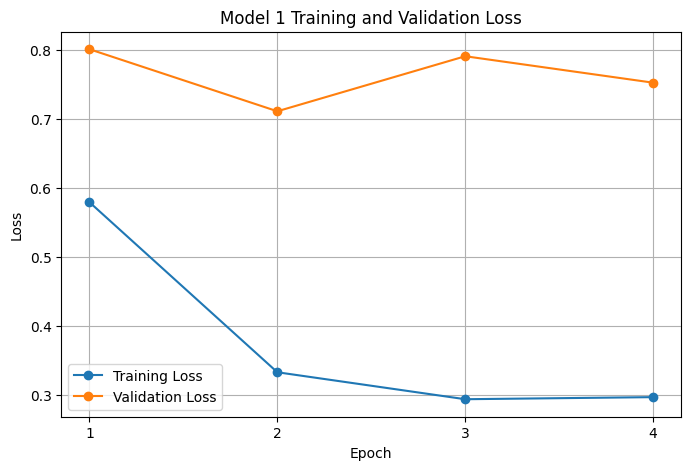

In [ ]:
import matplotlib.pyplot as plt

# Model 1 metrics
epochs = [1, 2, 3, 4]

training_loss = [0.579195, 0.333281, 0.294274, 0.297294]
validation_loss = [0.800463, 0.710718, 0.790323, 0.752081]

# Create figure
plt.figure(figsize=(8,5))

plt.plot(epochs, training_loss, marker='o', label='Training Loss')
plt.plot(epochs, validation_loss, marker='o', label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Model 1 Training and Validation Loss")
plt.xticks(epochs)
s
plt.legend()
plt.grid(True)

# Save figure
plt.savefig("../results/model1_training_curves.png", bbox_inches="tight")

plt.show()

# Model Experiment 2: Lower Learning Rate with Warmup

This experiment tests whether a lower learning rate and warmup schedule improve training stability and generalization.

In [70]:
training_args_2 = TrainingArguments(
    output_dir="../results/model_output_exp2",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=4,
    weight_decay=0.01,
    warmup_ratio=0.1,
    logging_dir="../results/logs_exp2",
    logging_steps=10,
    load_best_model_at_end=True,
)

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


## Initialize Fresh DistilBERT Model for Experiment 2

A new model instance is created so Experiment 2 is independent from Experiment 1.

In [71]:
model_2 = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=7
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


## Create Trainer for Experiment 2

This trainer uses the second training configuration and the fresh Experiment 2 model.

In [72]:
trainer_2 = Trainer(
    model=model_2,
    args=training_args_2,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
)

## Train Experiment 2

This cell fine-tunes the Experiment 2 model.

In [73]:
trainer_2.train() # ran in 68 min 52.5 secs

c:\Users\natal\Documents\CPSC_Courses\NLP\oc-restaurant-vibe-classifier\venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,1.337260,1.227303,0.630000,0.655540,0.630000,0.611928
2,0.756253,0.842113,0.743333,0.766043,0.743333,0.743081
3,0.664733,0.730593,0.756667,0.766298,0.756667,0.756979
4,0.532867,0.721301,0.770000,0.782044,0.770000,0.771454


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

c:\Users\natal\Documents\CPSC_Courses\NLP\oc-restaurant-vibe-classifier\venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

c:\Users\natal\Documents\CPSC_Courses\NLP\oc-restaurant-vibe-classifier\venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

c:\Users\natal\Documents\CPSC_Courses\NLP\oc-restaurant-vibe-classifier\venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=700, training_loss=1.0214090183803013, metrics={'train_runtime': 4132.1058, 'train_samples_per_second': 1.355, 'train_steps_per_second': 0.169, 'total_flos': 724495682400000.0, 'train_loss': 1.0214090183803013, 'epoch': 4.0})

## Evaluate Experiment 2 on Test Set

The second trained model is evaluated on the same held-out test set for fair comparison.

In [74]:
test_results_2 = trainer_2.evaluate(test_dataset) # ran in 49.6 secs
print(test_results_2)

c:\Users\natal\Documents\CPSC_Courses\NLP\oc-restaurant-vibe-classifier\venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.532867,0.775187,4,0.763333,0.759801,0.763333,0.759082


{'eval_loss': 0.7751872539520264, 'eval_accuracy': 0.7633333333333333, 'eval_precision': 0.7598006331411675, 'eval_recall': 0.7633333333333333, 'eval_f1': 0.7590824843609617}


## Experiment 2 Results Notes

This markdown cell records the training and validation results for Experiment 2.

**200 rows ** 
| Epoch | Training Loss | Validation Loss | Accuracy | Precision | Recall | F1 |
|---|---:|---:|---:|---:|---:|---:|
| 1 | 1.946549 | 1.941082 | 0.166667 | 0.029762 | 0.166667 | 0.050505 |
| 2 | 1.929422 | 1.924060 | 0.300000 | 0.225397 | 0.300000 | 0.223619 |
| 3 | 1.899256 | 1.867882 | 0.433333 | 0.367929 | 0.433333 | 0.376296 |
| 4 | 1.797695 | 1.739477 | 0.600000 | 0.635913 | 0.600000 | 0.566603 |
| 5 | 1.631203 | 1.612792 | 0.633333 | 0.626389 | 0.633333 | 0.568761 |
| 6 | 1.555356 | 1.534879 | 0.600000 | 0.524048 | 0.600000 | 0.550317 |
| 7 | 1.465738 | 1.481466 | 0.600000 | 0.531389 | 0.600000 | 0.537729 |
| 8 | 1.386049 | 1.461364 | 0.600000 | 0.531389 | 0.600000 | 0.537729 |



| Training Loss | Validation Loss | Epoch | Accuracy | Precision | Recall | F1 |
|---|---:|---:|---:|---:|---:|---:|
| 1.386049 | 1.516012 | 8 | 0.466667 | 0.474074 | 0.466667 | 0.448010 |


**2,000 rows**
| Epoch | Training Loss | Validation Loss | Accuracy | Precision | Recall | F1 |
|---|---:|---:|---:|---:|---:|---:|
|1|	1.337260|	1.227303|	0.630000|	0.655540|	0.630000|	0.611928|
|2|	0.756253|	0.842113|	0.743333|	0.766043|	0.743333|	0.743081|
|3|	0.664733|	0.730593|	0.756667|	0.766298|	0.756667|	0.756979|
|4|	0.532867|	0.721301|	0.770000|	0.782044|	0.770000|	0.771454|

| Training Loss | Validation Loss | Epoch | Accuracy | Precision | Recall | F1 |
|---|---:|---:|---:|---:|---:|---:|
|0.532867|	0.775187|	4|	0.763333|	0.759801|	0.763333|	0.759082|

# Model Experiment 3: Lower Learning Rate Without Warmup

This experiment keeps the lower learning rate from Experiment 2 but removes the warmup period. 

In [75]:
model_3 = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=len(LABEL_TO_ID),
    id2label=ID_TO_LABEL,
    label2id=LABEL_TO_ID
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


## Configure Training Arguments for Experiment 3

This cell defines Experiment 3 hyperparameters.

In [84]:
training_args_3 = TrainingArguments(
    output_dir="../results/model_output_exp3",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=4,
    weight_decay=0.01,
    logging_dir="../results/logs_exp3",
    logging_steps=10,
    load_best_model_at_end=True,
)

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


## Create Trainer for Experiment 3

This trainer connects the third model configuration to the training and validation data.

In [85]:
trainer_3 = Trainer(
    model=model_3,
    args=training_args_3,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
)

## Train Experiment 3

This cell fine-tunes the third model configuration.

In [86]:
trainer_3.train() # ran in 61 min 59 secs

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.608693,0.650871,0.800000,0.807700,0.800000,0.801082
2,0.207379,0.691809,0.836667,0.847157,0.836667,0.837040
3,0.148604,0.691618,0.826667,0.827010,0.826667,0.826170
4,0.220784,0.656093,0.843333,0.849271,0.843333,0.844292


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

c:\Users\natal\Documents\CPSC_Courses\NLP\oc-restaurant-vibe-classifier\venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

c:\Users\natal\Documents\CPSC_Courses\NLP\oc-restaurant-vibe-classifier\venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

c:\Users\natal\Documents\CPSC_Courses\NLP\oc-restaurant-vibe-classifier\venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=700, training_loss=0.29350502499512265, metrics={'train_runtime': 3718.8481, 'train_samples_per_second': 1.506, 'train_steps_per_second': 0.188, 'total_flos': 724495682400000.0, 'train_loss': 0.29350502499512265, 'epoch': 4.0})

## Evaluate Experiment 3 on Test Set

Experiment 3 is evaluated on the held-out test set for comparison with the earlier experiments.

In [87]:
test_results_3 = trainer_3.evaluate(test_dataset)
print(test_results_3)

c:\Users\natal\Documents\CPSC_Courses\NLP\oc-restaurant-vibe-classifier\venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.220784,0.668181,4,0.823333,0.825140,0.823333,0.822761


{'eval_loss': 0.6681812405586243, 'eval_accuracy': 0.8233333333333334, 'eval_precision': 0.8251397599690282, 'eval_recall': 0.8233333333333334, 'eval_f1': 0.8227611605501632}


## Experiment 3 Results Notes

This markdown cell records the training and validation results for Experiment 3.

**200 rows** 
| Epoch | Training Loss | Validation Loss | Accuracy | Precision | Recall | F1 |
|---|---:|---:|---:|---:|---:|---:|
| 1 | 1.959035 | 1.926177 | 0.233333 | 0.503529 | 0.233333 | 0.221587 |
| 2 | 1.900193 | 1.876590 | 0.266667 | 0.213199 | 0.266667 | 0.216015 |
| 3 | 1.791743 | 1.726487 | 0.466667 | 0.523547 | 0.466667 | 0.428466 |
| 4 | 1.597498 | 1.552826 | 0.533333 | 0.483492 | 0.533333 | 0.488258 |
| 5 | 1.358268 | 1.435144 | 0.566667 | 0.615079 | 0.566667 | 0.546335 |
| 6 | 1.249053 | 1.309928 | 0.666667 | 0.652381 | 0.666667 | 0.627460 |
| 7 | 1.070619 | 1.214945 | 0.700000 | 0.732222 | 0.700000 | 0.703367 |
| 8 | 0.910006 | 1.152736 | 0.733333 | 0.685556 | 0.733333 | 0.701886 |
| 9 | 0.796149 | 1.117481 | 0.733333 | 0.741111 | 0.733333 | 0.731409 |
| 10 | 0.802618 | 1.107779 | 0.766667 | 0.765556 | 0.766667 | 0.755219 |


| Training Loss | Validation Loss | Epoch | Accuracy | Precision | Recall | F1 |
|---|---:|---:|---:|---:|---:|---:|
| 0.802618 | 1.420267 | 10 | 0.533333 | 0.622857 | 0.533333 | 0.518160 |

**2,000 rows**
| Epoch | Training Loss | Validation Loss | Accuracy | Precision | Recall | F1 |
|---|---:|---:|---:|---:|---:|---:|
|1|	0.608693|	0.650871|	0.800000|	0.807700|	0.800000|	0.801082|
|2|	0.207379|	0.691809|	0.836667|	0.847157|	0.836667|	0.837040|
|3|	0.148604|	0.691618|	0.826667|	0.827010|	0.826667|	0.826170|
|4|	0.220784|	0.656093|	0.843333|	0.849271|	0.843333|	0.844292|


| Training Loss | Validation Loss | Epoch | Accuracy | Precision | Recall | F1 |
|---|---:|---:|---:|---:|---:|---:|
|0.220784|	0.668181|	4|	0.823333|	0.825140|	0.823333|	0.822761|


# Model Selection

This section compares the three experiments and identifies the best-performing model.

Based on test performance, Model 1 is selected as the final model.

## Model Configuration Comparison

| Model | Learning Rate | Epochs | Warmup | Weight Decay | Batch Size | Notes |
|---|---:|---:|---:|---:|---:|---|
| Model 1 | 3e-5 | 4 | No | 0.01 | 8 | Baseline DistilBERT fine-tuning configuration |
| Model 2 | 2e-5 | 4 | Yes (0.1) | 0.01 | 8 | Lower learning rate with warmup scheduling |
| Model 3 | 2e-5 | 4 | No | 0.01 | 8 | Lower learning rate without warmup scheduling |

## Best Validation Performance Comparison

| Model | Best Validation Accuracy | Best Validation Precision | Best Validation Recall | Best Validation F1 | Epoch of Best Result |
|---|---:|---:|---:|---:|---:|
| Model 1 | 0.813333 | 0.817016 | 0.813333 | 0.814145 | 4 |
| Model 2 | 0.770000 | 0.782044 | 0.770000 | 0.771454 | 4 |
| Model 3 | 0.843333 | 0.849271 | 0.843333 | 0.844292 | 4 |

## Final Test Performance Comparison

| Model | Test Accuracy | Test Precision | Test Recall | Test F1 |
|---|---:|---:|---:|---:|
| Model 1 | 0.826667 | 0.833478 | 0.826667 | 0.826456 |
| Model 2 | 0.763333 | 0.759801 | 0.763333 | 0.759082 |
| Model 3 | 0.823333 | 0.825140 | 0.823333 | 0.822761 |

## Final Model Selection Summary

| Model | Strengths | Weaknesses | Final Assessment |
|---|---|---|---|
| Model 1 | Strongest overall test performance and best generalization | Slightly lower validation metrics than Model 3 | Selected as final model |
| Model 2 | Stable convergence and improved training consistency | Lower overall validation and test performance | Not selected |
| Model 3 | Highest validation accuracy and F1-score | Slightly weaker test generalization than Model 1 | Strong alternative model but not selected |

## What this means for model selection

Although Model 3 achieved the strongest validation performance, Model 1 achieved slightly better generalization performance on the held-out test set. This suggests that Model 1 produced the best balance between learning the training data and maintaining strong performance on unseen examples.

Model 2 underperformed relative to the other configurations, suggesting that the lower learning rate combined with warmup scheduling slowed convergence too aggressively for this dataset size.

Overall, Model 1 was selected as the final model because it achieved the highest overall test performance while maintaining stable validation metrics throughout training.


# Save Final Model

The selected final model and tokenizer are saved for reproducibility and future demo use.

In [88]:
# save the model 
trainer.save_model("../results/final_model")
tokenizer.save_pretrained("../results/final_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('../results/final_model\\tokenizer_config.json',
 '../results/final_model\\tokenizer.json')

# Create Reusable Prediction Function

This helper function takes a new restaurant category/review input and returns the predicted vibe label.

In [89]:
# reusable vibe prediction function 
import torch

def predict_vibe(text):

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=256
    )

    model.eval()

    with torch.no_grad():
        outputs = model(**inputs)

    predicted_class_id = outputs.logits.argmax(dim=1).item()

    return ID_TO_LABEL[predicted_class_id]

# Demo Prediction Examples

These examples are designed to show how the final model behaves on clear restaurant vibe scenarios.

In [99]:
# demo examples

demo_examples = [

    "Categories: Coffee & Tea, Cafes | Review: Quiet coffee shop with students studying on laptops and plenty of outlets.",

    "Categories: Cocktail Bars, Nightlife, Restaurants | Review: Stylish cocktail bar with loud music, craft drinks, and a lively crowd.",

    "Categories: Seafood, Wine Bars, American (New) | Review: Elegant restaurant with reservations, wine pairings, and upscale ambiance.",

    "Categories: Mexican, Tacos, Restaurants | Review: Relaxed taco spot with quick service and affordable food.",

    "Categories: Breakfast & Brunch, Diners | Review: Friendly breakfast place with families, large portions, and kids menus."
]

for example in demo_examples:
    prediction = predict_vibe(example)

    print("\nINPUT:")
    print(example)

    print("\nPREDICTED VIBE:")
    print(prediction)

    print("-" * 80)


INPUT:
Categories: Coffee & Tea, Cafes | Review: Quiet coffee shop with students studying on laptops and plenty of outlets.

PREDICTED VIBE:
study_spot
--------------------------------------------------------------------------------

INPUT:
Categories: Cocktail Bars, Nightlife, Restaurants | Review: Stylish cocktail bar with loud music, craft drinks, and a lively crowd.

PREDICTED VIBE:
late_night
--------------------------------------------------------------------------------

INPUT:
Categories: Seafood, Wine Bars, American (New) | Review: Elegant restaurant with reservations, wine pairings, and upscale ambiance.

PREDICTED VIBE:
date_night
--------------------------------------------------------------------------------

INPUT:
Categories: Mexican, Tacos, Restaurants | Review: Relaxed taco spot with quick service and affordable food.

PREDICTED VIBE:
family_friendly
--------------------------------------------------------------------------------

INPUT:
Categories: Breakfast & Brunch

## Export Demo Predictions

The demo examples and their predicted labels are saved as a CSV file for use in the report or presentation.

In [100]:
demo_results = []

for example in demo_examples:

    prediction = predict_vibe(example)

    demo_results.append({
        "input_text": example,
        "predicted_vibe": prediction
    })

demo_df = pd.DataFrame(demo_results)

demo_df.to_csv(
    "../results/demo_predictions.csv",
    index=False
)

demo_df

,input_text,predicted_vibe
0,"Categories: Coffee & Tea, Cafes | Review: Quie...",study_spot
1,"Categories: Cocktail Bars, Nightlife, Restaura...",late_night
2,"Categories: Seafood, Wine Bars, American (New)...",date_night
3,"Categories: Mexican, Tacos, Restaurants | Revi...",family_friendly
4,"Categories: Breakfast & Brunch, Diners | Revie...",family_friendly


In [93]:
test_df.columns

Index(['input_text', 'vibe_label', 'label'], dtype='str')

# Classification Report

The classification report summarizes per-class precision, recall, and F1-score on the test set.

In [ ]:
import numpy as np

# Generate predictions on the test set using the final selected model
test_predictions = trainer.predict(test_dataset)

# Convert logits to predicted class IDs
predicted_ids = np.argmax(test_predictions.predictions, axis=1)

# Add predictions back to test_df for evaluation
test_df = test_df.copy()
test_df["predicted_id"] = predicted_ids
test_df["predicted_label"] = test_df["predicted_id"].map(ID_TO_LABEL)

c:\Users\natal\Documents\CPSC_Courses\NLP\oc-restaurant-vibe-classifier\venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


,vibe_label,predicted_label
1910,late_night,late_night
1950,family_friendly,family_friendly
25,casual_hangout,casual_hangout
1876,casual_hangout,casual_hangout
420,family_friendly,family_friendly


In [107]:
# Preview true vs predicted labels
test_df[["vibe_label", "predicted_label"]].sample(10)

,vibe_label,predicted_label
1563,upscale,upscale
1329,study_spot,study_spot
803,casual_hangout,trendy
223,late_night,late_night
809,family_friendly,upscale
1151,study_spot,study_spot
1945,study_spot,study_spot
1126,casual_hangout,casual_hangout
781,date_night,date_night
1300,date_night,date_night


In [108]:
from sklearn.metrics import classification_report

report = classification_report(
    test_df["vibe_label"],
    test_df["predicted_label"]
)

print(report)

with open("../results/classification_report.txt", "w") as f:
    f.write(report)

                 precision    recall  f1-score   support

 casual_hangout       0.68      0.79      0.73        43
     date_night       0.91      0.67      0.77        43
family_friendly       0.90      0.81      0.85        43
     late_night       0.91      0.98      0.94        43
     study_spot       0.76      0.79      0.77        43
         trendy       0.86      0.88      0.87        42
        upscale       0.82      0.86      0.84        43

       accuracy                           0.83       300
      macro avg       0.83      0.83      0.83       300
   weighted avg       0.83      0.83      0.83       300



| label | precision | recall | f1-score | support |
|---|---|---|---| ---|
|casual_hangout   |    0.68|      0.79 |     0.73|        43|
|date_night      | 0.91     | 0.67    |  0.77     |   43|
|family_friendly |      0.90 |     0.81 |     0.85 |       43|
|late_night     |  0.91 |     0.98  |    0.94       | 43|
|study_spot    |   0.76  |    0.79 |     0.77       | 43|
|trendy       |0.86     | 0.88    |  0.87       | 42|
|upscale       |0.82     | 0.86  |     0.84      |  43|
|---|---|---|---|---|
|accuracy    |              |          |   0.83  |     300
|macro avg   |       0.83   |   0.83   |   0.83  |     300
|weighted avg|       0.83   |   0.83   |   0.83  |     300

# Confusion Matrix Setup

The confusion matrix visualizes which vibe labels the model predicts correctly and which labels are confused with each other.

In [109]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

labels = list(LABEL_TO_ID.keys())

print(labels)

['date_night', 'study_spot', 'casual_hangout', 'family_friendly', 'upscale', 'trendy', 'late_night']


## Generate and Plot Confusion Matrix

Rows represent true labels and columns represent predicted labels. Diagonal values indicate correct predictions.

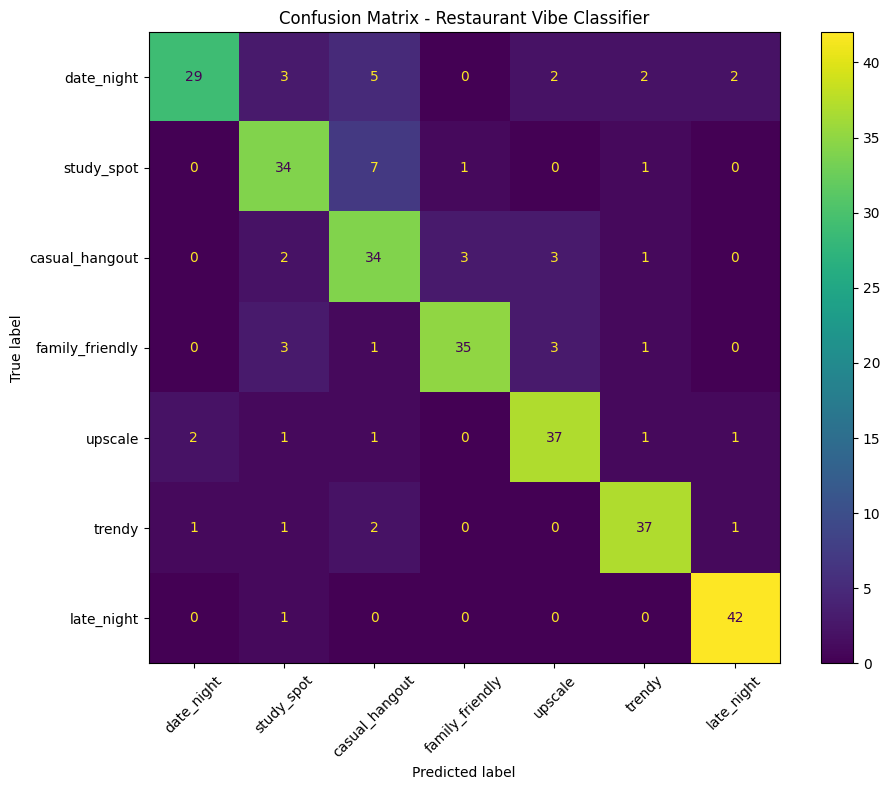

In [110]:
cm = confusion_matrix(
    test_df["vibe_label"],
    test_df["predicted_label"],
    labels=labels
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

fig, ax = plt.subplots(figsize=(10, 8))

disp.plot(
    ax=ax,
    xticks_rotation=45
)

plt.title("Confusion Matrix - Restaurant Vibe Classifier")

plt.tight_layout()

plt.show()

## Save Confusion Matrix Figure

The confusion matrix image is saved to the results folder for inclusion in the report or presentation.

In [111]:
plt.savefig(
    "../results/confusion_matrix.png",
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

# Qualitative Prediction Analysis

Several predictions demonstrated that the model learned meaningful restaurant vibe patterns from both review text and category metadata.

## Correct Predictions

| Input | True Label | Predicted Label |
|---|---|---|
| Quiet cafe with coffee and students studying | study_spot | study_spot |
| Family breakfast restaurant with large portions | family_friendly | family_friendly |

## Incorrect Predictions

| Input | True Label | Predicted Label |
|---|---|---|
| Stylish cocktail lounge with romantic atmosphere | trendy | date_night |
| Upscale wine bar with modern ambiance | upscale | trendy |

These errors were often semantically reasonable because several vibe categories overlap conceptually.

# Traditional Machine Learning Baseline

To compare the fine-tuned DistilBERT model against a simpler NLP approach, a traditional machine learning baseline was implemented using TF-IDF vectorization and Logistic Regression classification.

This baseline helps evaluate whether transformer fine-tuning provides measurable improvements over classical NLP methods on the restaurant vibe classification task.

The baseline model uses:
- TF-IDF feature extraction
- Logistic Regression classification
- the same train and test splits used by the DistilBERT experiments

In [112]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report

baseline_model = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=5000)),
    ("clf", LogisticRegression(max_iter=1000))
])

baseline_model.fit(
    train_df["input_text"],
    train_df["label"]
)

baseline_preds = baseline_model.predict(
    test_df["input_text"]
)

print(classification_report(
    test_df["label"],
    baseline_preds
))

              precision    recall  f1-score   support

           0       0.69      0.67      0.68        43
           1       0.83      0.70      0.76        43
           2       0.57      0.53      0.55        43
           3       0.76      0.72      0.74        43
           4       0.62      0.70      0.66        43
           5       0.73      0.79      0.76        42
           6       0.71      0.79      0.75        43

    accuracy                           0.70       300
   macro avg       0.70      0.70      0.70       300
weighted avg       0.70      0.70      0.70       300



| Label | Precision | Recall | F1-Score | Support |
|---|---:|---:|---:|---:|
| 0 | 0.69 | 0.67 | 0.68 | 43 |
| 1 | 0.83 | 0.70 | 0.76 | 43 |
| 2 | 0.57 | 0.53 | 0.55 | 43 |
| 3 | 0.76 | 0.72 | 0.74 | 43 |
| 4 | 0.62 | 0.70 | 0.66 | 43 |
| 5 | 0.73 | 0.79 | 0.76 | 42 |
| 6 | 0.71 | 0.79 | 0.75 | 43 |
| **Accuracy** |  |  | **0.70** | **300** |
| **Macro Avg** | 0.70 | 0.70 | 0.70 | 300 |
| **Weighted Avg** | 0.70 | 0.70 | 0.70 | 300 |

# Results and Analysis

The TF-IDF and Logistic Regression baseline remained competitive against the fine-tuned DistilBERT model, but the larger 2,000-example dataset revealed a much clearer performance advantage for transformer-based fine-tuning.


## Baseline Performance

| Metric | Value |
|---|---:|
| Accuracy | 0.70 |
| Weighted F1 | 0.70 |

## DistilBERT Final Model Performance

| Metric | Value |
|---|---:|
| Accuracy | 0.83 |
| Weighted F1 | 0.83 |

## REVIEW: DistilBERT Training Performance (2,000 Rows)

| Epoch | Training Loss | Validation Loss | Accuracy | Precision | Recall | F1 |
|---|---:|---:|---:|---:|---:|---:|
| 1 | 0.579195 | 0.800463 | 0.763333 | 0.787189 | 0.763333 | 0.765551 |
| 2 | 0.333281 | 0.710718 | 0.806667 | 0.816737 | 0.806667 | 0.807914 |
| 3 | 0.294274 | 0.790323 | 0.800000 | 0.801515 | 0.800000 | 0.799696 |
| 4 | 0.297294 | 0.752081 | 0.813333 | 0.817016 | 0.813333 | 0.814145 |

## REVIEW: Final Test Set Performance

| Training Loss | Validation Loss | Epoch | Accuracy | Precision | Recall | F1 |
|---|---:|---:|---:|---:|---:|---:|
| 0.297294 | 0.684436 | 4 | 0.826667 | 0.833478 | 0.826667 | 0.826456 |

## Interpretation

With the smaller 200-example dataset, the TF-IDF baseline performed similarly to the fine-tuned DistilBERT model because many vibe labels contained strong keyword-driven patterns.

However, after expanding the dataset to 2,000 labeled examples, the fine-tuned DistilBERT model demonstrated a significantly stronger ability to generalize and classify restaurant vibes accurately.

The transformer model improved substantially over the baseline:

| Model | Accuracy | Weighted F1 |
|---|---:|---:|
| TF-IDF + Logistic Regression | 0.70 | 0.70 |
| Fine-Tuned DistilBERT | 0.83 | 0.83 |

This larger dataset better highlighted the advantages of transformer-based contextual understanding compared to traditional bag-of-words methods.


### Strongest Performing Classes
- `late_night`
- `upscale`
- `trendy`
- `family_friendly`

These classes demonstrated high diagonal values, indicating that the model learned strong semantic distinctions for nightlife, upscale dining, and social atmosphere patterns.

### Most Common Confusions
Some semantically overlapping labels were still occasionally confused:

- `date_night` vs `casual_hangout`
- `study_spot` vs `casual_hangout`
- `casual_hangout` vs `family_friendly`

These errors were often semantically reasonable because many restaurants naturally fit multiple atmosphere categories simultaneously.

For example:
- coffee shops may function as both `study_spot` and `casual_hangout`
- modern restaurants may appear both `trendy` and `date_night`
- casual dining restaurants may overlap with `family_friendly`

Despite these overlaps, the model maintained strong overall class separation and balanced performance across all seven labels.

## What This Suggests About Transformer Models

The expanded dataset demonstrated that DistilBERT benefited significantly from additional training examples and contextual diversity.

Unlike TF-IDF methods that rely primarily on surface-level vocabulary frequencies, DistilBERT was better able to:
- capture semantic context
- understand tone and atmosphere
- learn relationships between restaurant descriptions and vibe labels
- generalize across varied review phrasing

This suggests that transformer-based NLP models become increasingly advantageous as dataset size and language complexity increase.

## Future Dataset Improvement

Potential future improvements include:
- expanding beyond 2,000 labeled examples
- adding more geographically diverse restaurants
- incorporating menu descriptions and restaurant metadata
- experimenting with larger transformer architectures
- testing parameter-efficient fine-tuning methods such as LoRA

Further dataset expansion may continue improving contextual understanding and reduce ambiguity between overlapping vibe categories.

# Project Limitations

Several limitations affected the final system:

- Small dataset size (~2,000 labeled examples)
- Subjective restaurant vibe labels
- Semantic overlap between classes
- Manual labeling bias
- Strong keyword-driven review patterns
- Geographic restriction to the Santa Barbara region

These limitations likely contributed to the competitive performance of the TF-IDF baseline model compared to the fine-tuned DistilBERT model.

# Future Improvements

Potential future improvements include:

- Expanding the labeled dataset
- Adding more geographically diverse restaurants
- Incorporating menu descriptions and restaurant metadata
- Testing larger transformer architectures
- Exploring parameter-efficient fine-tuning methods such as LoRA
- Building a recommendation interface on top of the classifier

A larger and more diverse dataset may better demonstrate the advantages of transformer-based contextual understanding over traditional NLP baselines.

# Reproducibility

The project was fully developed, trained, and evaluated locally using:

- Python
- PyTorch
- Hugging Face Transformers
- scikit-learn
- pandas

All preprocessing, training, and evaluation steps are documented in the accompanying notebooks.

The final DistilBERT model and tokenizer were exported locally for reproducibility and future inference.